# Credit Card Fraud — Exploratory Data Analysis

This notebook explores the Kaggle Credit Card Fraud Detection dataset (284,807 transactions, 492 fraud cases).
Features V1–V28 are PCA-anonymized; only `Time` and `Amount` are in original scale.
The goal is to understand class imbalance, feature distributions, and which PCA components correlate most with fraud — context that informs threshold selection in Phase 4.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw_data
from src.config import Config

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [2]:
df = load_raw_data(str(Config.DATA_PATH))

## 1. Basic overview

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print('Shape:', df.shape)
print()
df.dtypes

Shape: (284807, 31)



Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

## 2. Class distribution

In [5]:
counts = df['Class'].value_counts().rename({0: 'Legit', 1: 'Fraud'})
pct = (counts / counts.sum() * 100).round(3)
print(pd.DataFrame({'Count': counts, 'Pct %': pct}))

        Count   Pct %
Class                
Legit  284315  99.827
Fraud     492   0.173


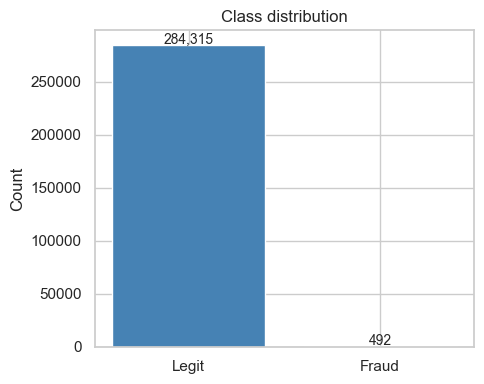

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Legit', 'Fraud'], counts.values, color=['steelblue', 'tomato'])
ax.set_ylabel('Count')
ax.set_title('Class distribution')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)
fig.tight_layout()
Config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(Config.FIGURES_DIR / 'class_distribution.png', dpi=150)
plt.show()

## 3. Amount distribution by class

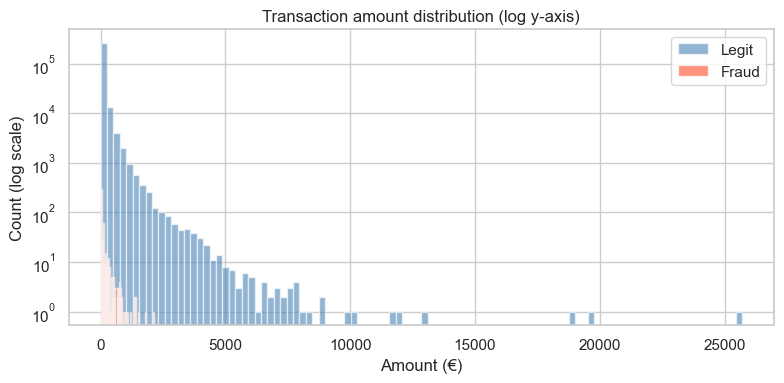

In [7]:
legit = df[df['Class'] == 0]['Amount']
fraud = df[df['Class'] == 1]['Amount']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(legit, bins=100, alpha=0.6, label='Legit', color='steelblue', log=True)
ax.hist(fraud, bins=50, alpha=0.7, label='Fraud', color='tomato', log=True)
ax.set_xlabel('Amount (€)')
ax.set_ylabel('Count (log scale)')
ax.set_title('Transaction amount distribution (log y-axis)')
ax.legend()
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / 'amount_by_class.png', dpi=150)
plt.show()

## 4. Time distribution by class

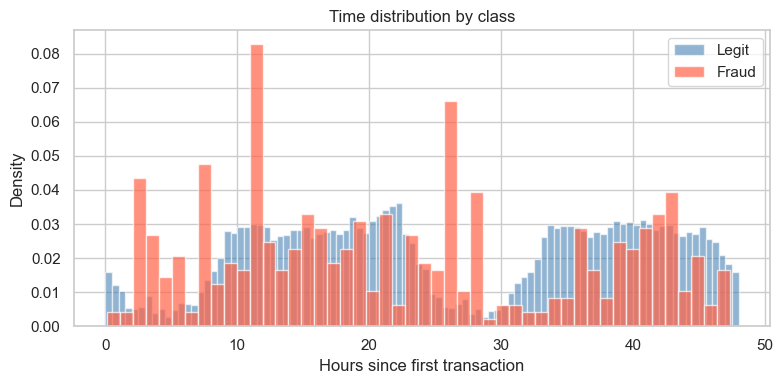

In [8]:
legit_t = df[df['Class'] == 0]['Time'] / 3600
fraud_t = df[df['Class'] == 1]['Time'] / 3600

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(legit_t, bins=96, alpha=0.6, label='Legit', color='steelblue', density=True)
ax.hist(fraud_t, bins=48, alpha=0.7, label='Fraud', color='tomato', density=True)
ax.set_xlabel('Hours since first transaction')
ax.set_ylabel('Density')
ax.set_title('Time distribution by class')
ax.legend()
fig.tight_layout()
plt.show()

## 5. Feature correlation with Class (V1–V28 + Time + Amount)

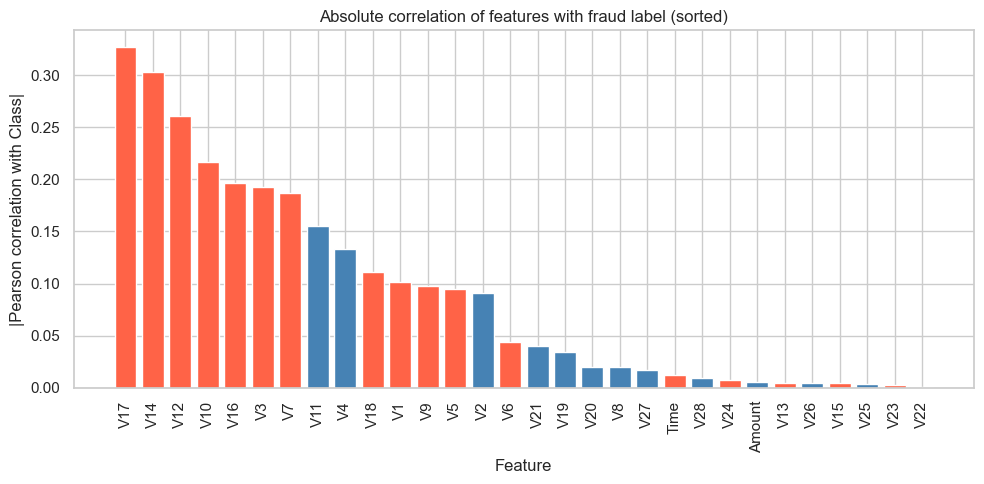

Top 5 correlated features:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64


In [9]:
feature_cols = [c for c in df.columns if c != 'Class']
corr = df[feature_cols + ['Class']].corr()['Class'].drop('Class')
corr_sorted = corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if corr[f] < 0 else 'steelblue' for f in corr_sorted.index]
ax.bar(corr_sorted.index, corr_sorted.values, color=colors)
ax.set_xlabel('Feature')
ax.set_ylabel('|Pearson correlation with Class|')
ax.set_title('Absolute correlation of features with fraud label (sorted)')
ax.tick_params(axis='x', rotation=90)
fig.tight_layout()
plt.show()

print('Top 5 correlated features:')
print(corr_sorted.head())

## Conclusions

- **Severe class imbalance:** only 0.17% of transactions are fraud (492 out of 284,807). This rules out naive accuracy as a metric and motivates the autoencoder's unsupervised framing — training only on legitimate transactions sidesteps the need to balance classes.
- **Amount skew:** both classes concentrate at low amounts, but fraud extends less far into high values than legit. The raw scale difference (max legit ~25k vs. fraud ~2.1k) makes `StandardScaler` important before feeding the model.
- **Time shows no clear fraud spike:** fraud is distributed across both day cycles, so `Time` is unlikely to be a strong standalone discriminator, though it is kept as a feature.
- **V14, V12, V10 are the most correlated PCA components with fraud** (|r| > 0.3). The autoencoder will implicitly capture these patterns through reconstruction error, without any label supervision.